# Automated Vegetation Monitoring for Transmission Corridors
**Objective:** Programmatically generate a 2-mile biological survey corridor, retrieve real-time Sentinel-2 satellite imagery via the STAC API, and calculate the Normalized Difference Vegetation Index (NDVI) to automate potential hazard-tree mitigation.

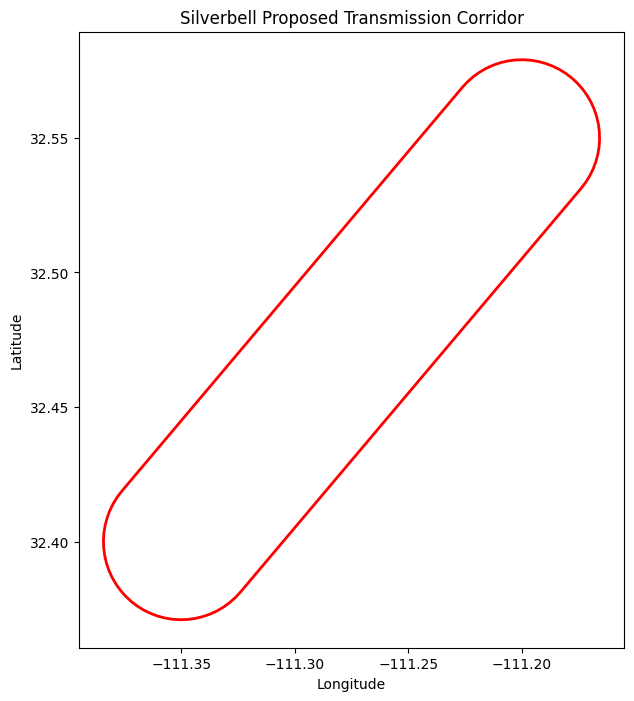

In [2]:
import geopandas as gpd
from shapely.geometry import LineString
import matplotlib.pyplot as plt

# 1. Define our Silverbell transmission line route
start_point = (-111.350, 32.400) 
end_point = (-111.200, 32.550)    
corridor_line = LineString([start_point, end_point])

# 2. Build the GeoDataFrame with a properly named column
gdf = gpd.GeoDataFrame({"id": [1]}, geometry=[corridor_line], crs="EPSG:4326")
gdf_utm = gdf.to_crs("EPSG:26912")

# 3. Buffer by ~2 miles (3218 meters) and project back
gdf_utm['geometry'] = gdf_utm.geometry.buffer(3218)
corridor = gdf_utm.to_crs("EPSG:4326")

# 4. Save it for later, but also PLOT it right here
corridor.to_file("../data/raw/silverbell_corridor.geojson", driver="GeoJSON")

# Visual verification
corridor.plot(color='none', edgecolor='red', linewidth=2, figsize=(8,8))
plt.title("Silverbell Proposed Transmission Corridor")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [3]:
from pystac_client import Client
import json

print("1. Extracting Bounding Box from corridor geometry...")
# A Bounding Box is just [min_lon, min_lat, max_lon, max_lat]
bbox = corridor.total_bounds.tolist()
print(f"   Project Bounding Box: {bbox}")

print("\n2. Connecting to Earth Search STAC API...")
# This is the public AWS STAC catalog for Sentinel-2 satellite data
catalog = Client.open("https://earth-search.aws.element84.com/v1")

print("\n3. Searching for cloud-free Sentinel-2 imagery...")
# We query the exact collection, location, timeframe, and weather conditions
search = catalog.search(
    collections=["sentinel-2-l2a"],  # Level-2A is Surface Reflectance (Atmospherically corrected)
    bbox=bbox,
    datetime="2026-04-01/2026-05-01", # Looking at data from April 2026
    query={"eo:cloud_cover": {"lt": 5}}  # Less than 5% cloud cover
)

items = list(search.items())
print(f"\nSuccess! Found {len(items)} pristine satellite scenes.")

if items:
    # Grab the first item (the STAC API defaults to the most recent scene)
    best_item = items[0] 
    print(f"   Selected Scene Date: {best_item.datetime}")
    print(f"   Scene ID: {best_item.id}")
    
    # Save this metadata payload so our next script knows exactly what links to download
    output_meta = '../data/processed/selected_scene.json'
    with open(output_meta, 'w') as f:
        json.dump(best_item.to_dict(), f)
    print(f"\nScene metadata locked into: {output_meta}")
else:
    print("\nNo scenes found. We may need to expand the date range or allow more clouds.")

1. Extracting Bounding Box from corridor geometry...
   Project Bounding Box: [-111.3842140954763, 32.37097332577028, -111.16572985273662, 32.57902546426642]

2. Connecting to Earth Search STAC API...

3. Searching for cloud-free Sentinel-2 imagery...

Success! Found 5 pristine satellite scenes.
   Selected Scene Date: 2026-04-18 18:15:20.451000+00:00
   Scene ID: S2C_12SVA_20260418_0_L2A

Scene metadata locked into: ../data/processed/selected_scene.json


In [4]:
import json
import requests

print("1. Accessing STAC metadata...")
with open('../data/processed/selected_scene.json', 'r') as f:
    scene_meta = json.load(f)

# 2. Extract the direct URLs for the Red and NIR spectral bands
red_url = scene_meta['assets']['red']['href']
nir_url = scene_meta['assets']['nir']['href']

print(f"   Target Acquired: Red Band -> {red_url.split('/')[-1]}")
print(f"   Target Acquired: NIR Band -> {nir_url.split('/')[-1]}")

# 3. Define a function to stream the large satellite files to your hard drive
def download_band(url, filename):
    filepath = f"../data/raw/{filename}"
    print(f"\nDownloading {filename}... (This may take a minute)")
    
    # We use stream=True so we don't crash your computer's RAM with massive files
    response = requests.get(url, stream=True)
    with open(filepath, 'wb') as file:
        for chunk in response.iter_content(chunk_size=8192):
            file.write(chunk)
    print(f"Successfully saved to {filepath}")

# 4. Execute the targeted downloads
download_band(red_url, "sentinel_red.tif")
download_band(nir_url, "sentinel_nir.tif")

print("\nPhase B Data Acquisition Complete. Ready for Rasterio.")

1. Accessing STAC metadata...
   Target Acquired: Red Band -> B04.tif
   Target Acquired: NIR Band -> B08.tif

Successfully saved to ../data/raw/sentinel_red.tif

Successfully saved to ../data/raw/sentinel_nir.tif

Phase B Data Acquisition Complete. Ready for Rasterio.


1. Loading spectral arrays into memory...
   Grid Size: 10980 rows by 10980 columns.

2. Executing NDVI Pixel Math...

3. Rendering Vegetation Health Map...


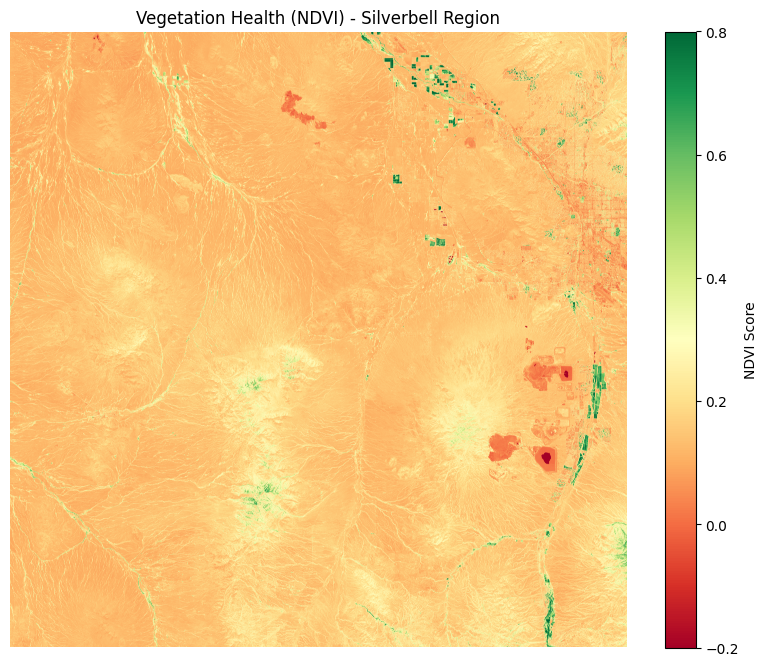


Success! Processed NDVI spatial raster saved to: ../data/processed/silverbell_ndvi.tif


In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

print("1. Loading spectral arrays into memory...")
# Open the downloaded files and read the pixel data as decimal numbers (float32)
with rasterio.open('../data/raw/sentinel_red.tif') as src_red:
    red = src_red.read(1).astype('float32')
    # We also grab the spatial metadata (the "profile") so we can export the result later
    meta = src_red.profile

with rasterio.open('../data/raw/sentinel_nir.tif') as src_nir:
    nir = src_nir.read(1).astype('float32')

print(f"   Grid Size: {red.shape[0]} rows by {red.shape[1]} columns.")

print("\n2. Executing NDVI Pixel Math...")
# Satellite data often has "empty" pixels at the edges that equal 0. 
# We tell NumPy to safely ignore division-by-zero errors to prevent crashes.
np.seterr(divide='ignore', invalid='ignore')

# The Core Formula
ndvi = np.where(
    (nir + red) == 0., 
    0, 
    (nir - red) / (nir + red)
)

print("\n3. Rendering Vegetation Health Map...")
# Plot the massive array as a color-coded map
plt.figure(figsize=(10, 8))
# 'RdYlGn' maps Red to bare soil/rock, Yellow to sparse scrub, and Green to dense vegetation
plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
plt.colorbar(label='NDVI Score')
plt.title("Vegetation Health (NDVI) - Silverbell Region")
plt.axis('off') # Hide the raw pixel grid numbers
plt.show()

# 4. Save the calculated array as a brand new spatial file
output_tif = '../data/processed/silverbell_ndvi.tif'

# Update the metadata to reflect our new single-band math product
meta.update(
    dtype=rasterio.float32,
    count=1,
    compress='lzw'
)

with rasterio.open(output_tif, 'w', **meta) as dst:
    dst.write(ndvi.astype(rasterio.float32), 1)

print(f"\nSuccess! Processed NDVI spatial raster saved to: {output_tif}")

In [2]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np

print("1. Loading Corridor and NDVI Data...")
corridor = gpd.read_file('../data/raw/silverbell_corridor.geojson')

with rasterio.open('../data/processed/silverbell_ndvi.tif') as src:
    print(f"   Satellite CRS: {src.crs}")
    print(f"   Corridor CRS:  {corridor.crs}")
    
    # 2. The Projection Trap: Aligning the CRS dynamically
    if corridor.crs != src.crs:
        print("\n   [!] CRS Mismatch Detected! Reprojecting corridor to match satellite data...")
        corridor = corridor.to_crs(src.crs)
    
    print("\n3. Cookie-cutting the pixels...")
    # Extract the mathematical geometry from the GeoDataFrame
    shapes = [geom for geom in corridor.geometry]
    
    # Mask the raster. 'crop=True' deletes all the pixels outside our corridor boundary.
    out_image, out_transform = mask(src, shapes, crop=True)

print("\n4. Calculating Corridor Vegetation Statistics...")
# We filter the array to only include valid NDVI values (between -1.0 and 1.0)
# This ignores the "empty" background pixels created by the cookie-cutter
valid_pixels = out_image[(out_image >= -1.0) & (out_image <= 1.0)]

mean_ndvi = np.mean(valid_pixels)
max_ndvi = np.max(valid_pixels)

print(f"   Total Pixels Inside Corridor: {len(valid_pixels):,}")
print(f"   Average Corridor Health (NDVI): {mean_ndvi:.3f}")
print(f"   Peak Vegetation Score: {max_ndvi:.3f}")

print("\n--- AUTOMATED MITIGATION REPORT ---")
if mean_ndvi > 0.25:
    print("🚨 WARNING: High average vegetation density detected within the transmission footprint. Hazard tree clearing and NEPA mitigation required.")
elif mean_ndvi > 0.1:
    print("⚠️ ADVISORY: Moderate scrub vegetation detected. Standard construction clearance approved.")
else:
    print("✅ CLEAR: Corridor is predominantly bare soil or rock. No immediate vegetation mitigation required.")

1. Loading Corridor and NDVI Data...
   Satellite CRS: EPSG:32612
   Corridor CRS:  EPSG:4326

   [!] CRS Mismatch Detected! Reprojecting corridor to match satellite data...

3. Cookie-cutting the pixels...

4. Calculating Corridor Vegetation Statistics...
   Total Pixels Inside Corridor: 3,786,501
   Average Corridor Health (NDVI): 0.066
   Peak Vegetation Score: 0.921

--- AUTOMATED MITIGATION REPORT ---
✅ CLEAR: Corridor is predominantly bare soil or rock. No immediate vegetation mitigation required.
